# 3. SARIMA solar: versión no bayesiana

## Objetivo

Construir un primer modelo $\operatorname{SARIMA}(1,0,0)(1,1,0)_{24}$
para la generación solar. El ajuste usa máxima verosimilitud. Después
traduciremos exactamente esta dinámica a Stan y reemplazaremos una estimación
puntual por una distribución posterior.

Trabajaremos por etapas:

1. acotar y transformar la generación;
2. remover el ciclo diario;
3. ajustar un SARIMA clásico;
4. pronosticar una semana;
5. construir los vectores que necesitará Stan.


## Modelo que estudiaremos

Primero aplicamos una diferencia estacional de periodo \(24\):

$
w_t=z_t-z_{t-24}.
$

Después modelamos la serie transformada \(w_t\) mediante

$
\boxed{
w_t=c+\phi w_{t-1}+\Phi w_{t-24}
-\phi\Phi w_{t-25}+\varepsilon_t,
\qquad
\varepsilon_t\sim N(0,\sigma^2).
}
$

La notación correspondiente es

$
\operatorname{SARIMA}(1,0,0)(1,1,0)_{24}.
$

La interacción en el rezago \(25=1+24\) aparece al multiplicar los dos
polinomios autorregresivos.


## Deducción paso a paso de la ecuación

Partimos de

$
\operatorname{SARIMA}(1,0,0)(1,1,0)_{24}.
$

### Paso 1: diferencia estacional

Como \(D=1\) y el periodo estacional es \(s=24\), definimos

$
\boxed{
w_t=(1-B^{24})z_t=z_t-z_{t-24}.
}
$

Aquí \(B\) es el operador de rezago:

$
Bz_t=z_{t-1},
\qquad
B^{24}z_t=z_{t-24}.
$

### Paso 2: polinomios AR

La parte AR de corto plazo, \(p=1\), es

$
1-\phi B.
$

La parte AR diaria, \(P=1\), es

$
1-\Phi B^{24}.
$

Por tanto, sobre la serie diferenciada \(w_t\), escribimos

$
(1-\phi B)(1-\Phi B^{24})w_t=c+\varepsilon_t.
$

### Paso 3: multiplicar los polinomios

$
\begin{aligned}
(1-\phi B)(1-\Phi B^{24})
&=1-\phi B-\Phi B^{24}+\phi\Phi B^{25}.
\end{aligned}
$

El rezago \(25\) aparece porque $B B^{24}=B^{25}$.

### Paso 4: aplicar el operador a \(w_t\)

$
w_t-\phi w_{t-1}-\Phi w_{t-24}
+\phi\Phi w_{t-25}
=c+\varepsilon_t.
$

Finalmente, aislamos \(w_t\):

$
\boxed{
w_t=c+\phi w_{t-1}+\Phi w_{t-24}
-\phi\Phi w_{t-25}+\varepsilon_t,
\qquad
\varepsilon_t\sim N(0,\sigma^2).
}
$

Esta es exactamente la ecuación que pasaremos a Stan mediante los vectores
response, lag1, lag24 y lag25.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

SEED = 20260917
rng = np.random.default_rng(SEED)


## 1. Datos y partición temporal

In [2]:
df = pd.read_csv("data/solar_8760h.csv")
df.index = pd.date_range("2019-01-01", periods=len(df), freq="h")

y = df["pv_kw_per_kwp"].to_numpy(float)
H = 168
cutoff = len(y) - H
train, observed = y[:cutoff], y[cutoff:]
test_index = df.index[cutoff:]

print(f"Entrenamiento: {len(train)} horas")
print(f"Pronóstico:    {len(observed)} horas")


Entrenamiento: 8592 horas
Pronóstico:    168 horas


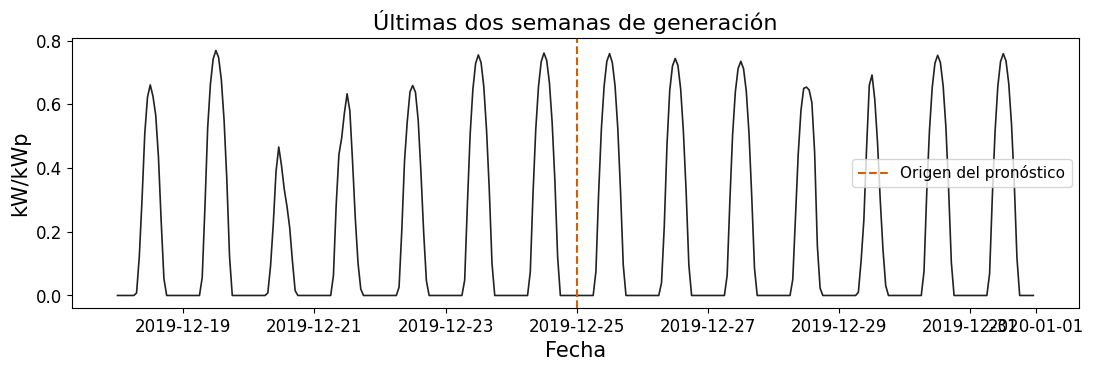

In [3]:
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(df.index[-24 * 14:], y[-24 * 14:], color="#222222", lw=1.2)
ax.axvline(test_index[0], color="#D55E00", ls="--", label="Origen del pronóstico")
ax.set(title="Últimas dos semanas de generación", xlabel="Fecha", ylabel="kW/kWp")
ax.legend()
plt.show()


## 2. Transformación y diferencia estacional

La producción se encuentra aproximadamente entre \(0\) y \(1\). Para usar un
modelo normal sin generar pronósticos imposibles, trabajamos en la escala

$
z_t=\operatorname{logit}\left(\frac{y_t+\epsilon}{1+2\epsilon}\right).
$

Usaremos sólo los últimos 120 días de entrenamiento para que el ejercicio sea
ligero. Después calcularemos \(w_t=z_t-z_{t-24}\).


In [4]:
EPS = 0.005

def to_z(values):
    p = (np.asarray(values, float) + EPS) / (1 + 2 * EPS)
    return np.log(p / (1 - p))

def from_z(values):
    return np.clip((1 + 2 * EPS) * expit(values) - EPS, 0, 1)

z_train = to_z(train[-24 * 120:])


### Actividad 1

Completa la diferencia estacional. Verifica que \(w_t\) tenga 24 observaciones
menos que \(z_t\).


In [5]:
# Escribe aquí tu solución:
#
# w = ...
# assert len(w) == len(z_train) - 24


In [6]:
# Solución de referencia
w = z_train[24:] - z_train[:-24]
assert len(w) == len(z_train) - 24
print("Longitud de z:", len(z_train), "| Longitud de w:", len(w))


Longitud de z: 2880 | Longitud de w: 2856


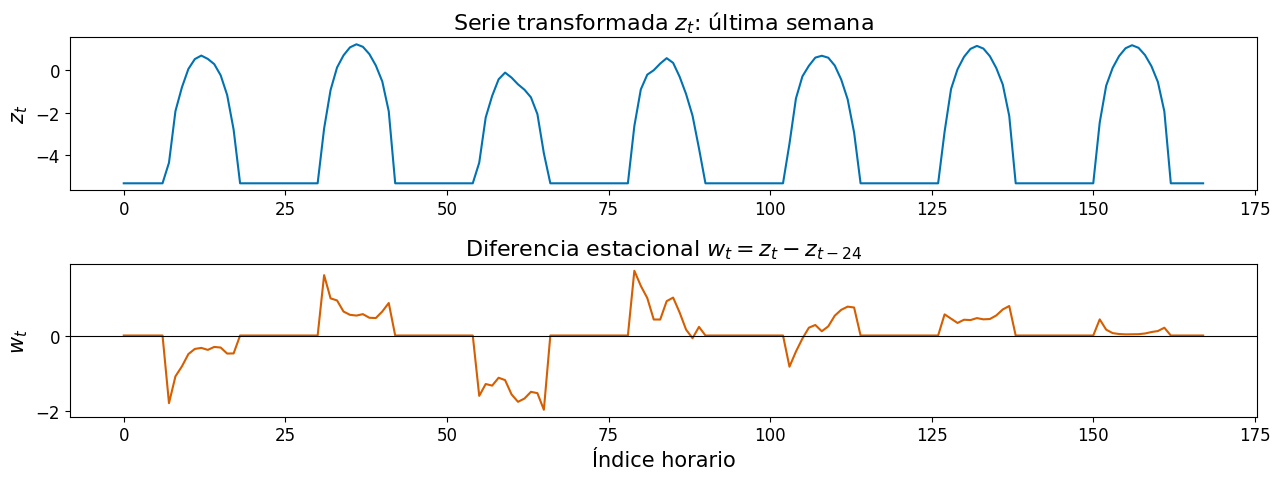

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=False)
axes[0].plot(z_train[-24 * 7:], color="#0072B2")
axes[0].set(title=r"Serie transformada $z_t$: última semana", ylabel=r"$z_t$")
axes[1].plot(w[-24 * 7:], color="#D55E00")
axes[1].axhline(0, color="black", lw=.8)
axes[1].set(title=r"Diferencia estacional $w_t=z_t-z_{t-24}$", ylabel=r"$w_t$", xlabel="Índice horario")
fig.tight_layout()
plt.show()


## 3. Ajuste SARIMA clásico

En la clase SARIMAX, la parte no estacional se escribe como
order=(p,d,q) y la parte diaria como seasonal_order=(P,D,Q,s).

Para este ejercicio:

\[
(p,d,q)=(1,0,0),
\qquad
(P,D,Q,s)=(1,1,0,24).
\]


### Actividad 2

In [8]:
# Completa estos argumentos:
#
# order = (...)
# seasonal_order = (...)
# model = SARIMAX(z_train, order=order, seasonal_order=seasonal_order, trend="c",
#                 enforce_stationarity=False, enforce_invertibility=False)
# fit = model.fit(disp=False)


In [9]:
# Solución de referencia
order = (1, 0, 0)
seasonal_order = (1, 1, 0, 24)
model = SARIMAX(
    z_train,
    order=order,
    seasonal_order=seasonal_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)
fit = model.fit(disp=False)

display(fit.summary().tables[1])


,coef,std err,z,P>|z|,[0.025,0.975]
intercept,-0.0001,0.004,-0.031,0.975,-0.008,0.007
ar.L1,0.8641,0.006,138.277,0.000,0.852,0.876
ar.S.L24,-0.4217,0.006,-72.357,0.000,-0.433,-0.410
sigma2,0.0368,0.000,125.967,0.000,0.036,0.037


### Interpretación

El ajuste clásico entrega un valor estimado para cada parámetro. En la tabla,
busca ar.L1, ar.S.L24 y sigma2:

- ar.L1 estima \(\phi\), memoria de una hora;
- ar.S.L24 estima \(\Phi\), memoria de un día;
- sigma2 estima la variabilidad de las innovaciones.

En Stan estos parámetros no serán números fijos: tendrán una distribución
posterior.


## 4. Pronóstico de una semana

### Actividad 3

Usa el método get_forecast para generar \(H=168\) pasos futuros. El modelo
produce el pronóstico en escala \(z\); conviértelo de nuevo a escala de
generación con from_z.


In [10]:
# Escribe aquí tu solución:
#
# forecast_z = ...
# forecast = ...
# lower_z = ...
# upper_z = ...


In [11]:
# Solución de referencia
forecast_result = fit.get_forecast(steps=H)
forecast_z = forecast_result.predicted_mean
interval_z = forecast_result.conf_int(alpha=0.10)

forecast = from_z(forecast_z)
lower = from_z(interval_z[:, 0])
upper = from_z(interval_z[:, 1])


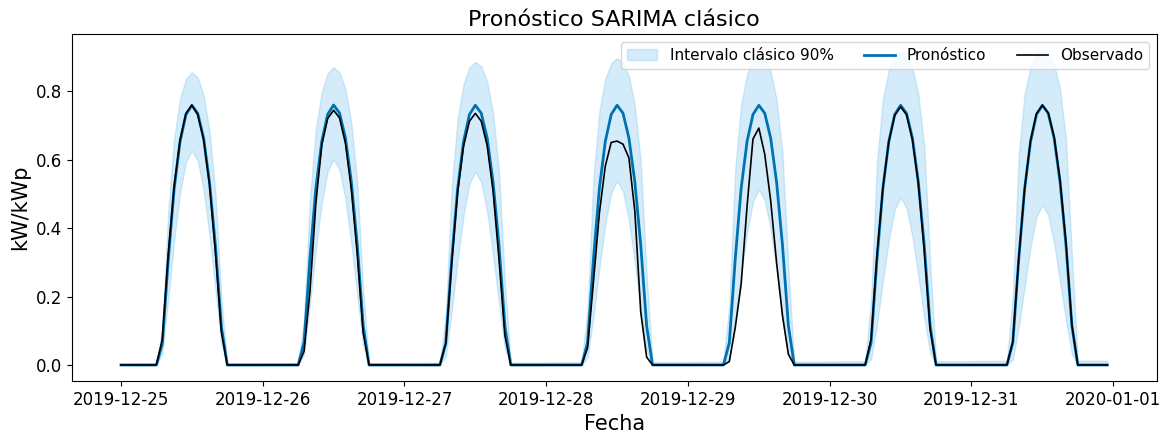

In [12]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.fill_between(test_index, lower, upper, color="#56B4E9", alpha=.25, label="Intervalo clásico 90%")
ax.plot(test_index, forecast, color="#0072B2", lw=2, label="Pronóstico")
ax.plot(test_index, observed, color="black", lw=1.2, label="Observado")
ax.set(title="Pronóstico SARIMA clásico", xlabel="Fecha", ylabel="kW/kWp")
ax.legend(ncol=3)
plt.show()


### Actividad 4

In [13]:
# Completa las dos métricas:
#
# mae = ...
# rmse = ...
# print(f"MAE = {mae:.4f} | RMSE = {rmse:.4f}")


In [14]:
# Solución de referencia
mae = np.mean(np.abs(observed - forecast))
rmse = np.sqrt(np.mean((observed - forecast) ** 2))
coverage = np.mean((observed >= lower) & (observed <= upper))
print(f"MAE = {mae:.4f} | RMSE = {rmse:.4f} | Cobertura 90% = {coverage:.1%}")


MAE = 0.0199 | RMSE = 0.0511 | Cobertura 90% = 95.8%


## Guardar el pronóstico

In [15]:
# En este modelo clásico, q05 y q95 corresponden a los extremos
# del intervalo de pronóstico al 90% calculado por SARIMAX.
results_dir = Path("resultados")
results_dir.mkdir(exist_ok=True)

forecast_table = pd.DataFrame({
    "fecha": test_index,
    "observado": observed,
    "q05": lower,
    "q50": forecast,
    "q95": upper,
})
forecast_file = results_dir / "forecast_sarima_solar_no_bayesian.csv"
forecast_table.to_csv(forecast_file, index=False)
print(f"Predicciones guardadas en: {forecast_file}")
display(forecast_table.head())


Predicciones guardadas en: resultados/forecast_sarima_solar_no_bayesian.csv


,fecha,observado,q05,q50,q95
0,2019-12-25 00:00:00,0.0,0.0,0.0,0.001840
1,2019-12-25 01:00:00,0.0,0.0,0.0,0.002564
2,2019-12-25 02:00:00,0.0,0.0,0.0,0.003043
3,2019-12-25 03:00:00,0.0,0.0,0.0,0.003380
4,2019-12-25 04:00:00,0.0,0.0,0.0,0.003623


## 5. Puente hacia Stan

Stan no necesita la clase SARIMAX. Le pasaremos los rezagos de la ecuación
expandida:

$
w_t=c+\phi w_{t-1}+\Phi w_{t-24}-\phi\Phi w_{t-25}+\varepsilon_t.
$

Por eso necesitamos una respuesta y tres vectores de rezagos.


### Actividad 5

In [16]:
# Construye los cuatro vectores. Todos deben tener la misma longitud:
#
# response = ...
# lag1 = ...
# lag24 = ...
# lag25 = ...


In [17]:
# Solución de referencia
response = w[25:]
lag1 = w[24:-1]
lag24 = w[1:-24]
lag25 = w[:-25]

assert len({len(response), len(lag1), len(lag24), len(lag25)}) == 1
stan_data = {
    "N": len(response),
    "response": response,
    "lag1": lag1,
    "lag24": lag24,
    "lag25": lag25,
}
print({name: np.asarray(values).shape for name, values in stan_data.items() if name != "N"})


{'response': (2831,), 'lag1': (2831,), 'lag24': (2831,), 'lag25': (2831,)}


## Qué cambia al pasar a Stan

En este notebook, SARIMAX estima un conjunto de valores:

$
\widehat c,\quad\widehat\phi,\quad\widehat\Phi,\quad\widehat\sigma.
$

En Stan asignaremos priors y obtendremos muestras:

$
(c^{(m)},\phi^{(m)},\Phi^{(m)},\sigma^{(m)}),
\qquad m=1,\ldots,M.
$

Con cada muestra simularemos una trayectoria futura. El enfoque bayesiano
propaga la incertidumbre de los parámetros y la de las innovaciones futuras.
